#### installing libraries

In [1]:
# pip install numpy

In [2]:
# pip install pandas

In [3]:
# pip install snowflake-connector-python

In [4]:
# pip install jupyter_scheduler

In [5]:
# pip install snowflake-sqlalchemy

In [6]:
# pip install "snowflake-connector-python[pandas]"

#### Connecting to Snowflake

In [7]:
import numpy as np
import pandas as pd
import ydata_profiling
import matplotlib.pyplot as plt
import getpass
import seaborn as sns 
%matplotlib inline
import snowflake.connector

In [8]:
conn = snowflake.connector.connect(
        user = 'Moni',
        # password = getpass.getpass('Your Snowflake Password is'),
         password='Moni@1234567890',
        account = 'CNXLYPS-NB32912',
        database = 'RETAILS',
        schema = 'PUBLIC',
        warehouse = 'COMPUTE_WH',
)

In [9]:
cur = conn.cursor()

In [10]:
cur

In [11]:
select_demographic_RAW = 'SELECT * FROM demographic_RAW'
select_CAMPAIGN_DESC_RAW = 'SELECT * FROM CAMPAIGN_DESC_RAW'
select_CAMPAIGN_RAW = 'SELECT * FROM CAMPAIGN_RAW'
select_PRODUCT_RAW = 'SELECT * FROM PRODUCT_RAW'
select_COUPON_RAW = 'SELECT * FROM COUPON_RAW'
select_COUPON_REDEMPT_RAW = 'SELECT * FROM COUPON_REDEMPT_RAW'
select_TRANSACTION_RAW = 'SELECT * FROM TRANSACTION_RAW'

In [12]:
cur.execute(select_demographic_RAW)
demographic_RAW = cur.fetch_pandas_all()

In [13]:
cur.execute(select_CAMPAIGN_DESC_RAW)
CAMPAIGN_DESC_RAW = cur.fetch_pandas_all()

In [14]:
cur.execute(select_CAMPAIGN_RAW)
CAMPAIGN_RAW = cur.fetch_pandas_all()

In [15]:
cur.execute(select_PRODUCT_RAW)
PRODUCT_RAW = cur.fetch_pandas_all()

In [16]:
cur.execute(select_COUPON_RAW)
COUPON_RAW = cur.fetch_pandas_all()

In [17]:
cur.execute(select_COUPON_REDEMPT_RAW)
COUPON_REDEMPT_RAW = cur.fetch_pandas_all()

In [18]:
cur.execute(select_TRANSACTION_RAW)
TRANSACTION_RAW = cur.fetch_pandas_all()

In [19]:
cur.close()
conn.close()

In [20]:
demographic_RAW.head(5)

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,HOUSEHOLD_KEY
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [21]:
CAMPAIGN_DESC_RAW.head(5)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684


In [22]:
CAMPAIGN_RAW.head(5)

,DESCRIPTION,HOUSEHOLD_KEY,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [23]:
PRODUCT_RAW.head(5)

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [24]:
COUPON_RAW.head(5)

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [25]:
COUPON_REDEMPT_RAW.head(5)

,HOUSEHOLD_KEY,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


In [26]:
TRANSACTION_RAW.head(5)

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2056,29330027026,177,1106523,1,2.32,341,0.00,4,26,0,0
1,2056,29330027026,177,5567325,1,2.69,341,0.00,4,26,0,0
2,2056,29330027027,177,1106523,1,2.32,341,0.00,4,26,0,0
3,1873,29330097522,177,1135681,1,1.29,320,0.00,1,26,0,0
4,1602,29339301484,177,828427,1,0.22,334,-0.07,1537,26,0,0


In [27]:
demographic_RAW.shape

(2500, 8)

In [28]:
CAMPAIGN_DESC_RAW.shape

(30, 4)

In [29]:
CAMPAIGN_RAW.shape

(7208, 3)

In [30]:
PRODUCT_RAW.shape

(92353, 7)

In [31]:
COUPON_RAW.shape

(124548, 3)

In [32]:
COUPON_REDEMPT_RAW.shape

(2318, 4)

In [33]:
TRANSACTION_RAW.shape

(1858364, 12)

In [34]:
demographic_RAW.dtypes

AGE_DESC               object
MARITAL_STATUS_CODE    object
INCOME_DESC            object
HOMEOWNER_DESC         object
HH_COMP_DESC           object
HOUSEHOLD_SIZE_DESC    object
KID_CATEGORY_DESC      object
HOUSEHOLD_KEY           int16
dtype: object

In [35]:
demographic_RAW.describe()

,HOUSEHOLD_KEY
count,2500.00000
mean,1250.50000
std,721.83216
min,1.00000
25%,625.75000
50%,1250.50000
75%,1875.25000
max,2500.00000


In [36]:
demographic_RAW.isnull().sum()

AGE_DESC               0
MARITAL_STATUS_CODE    0
INCOME_DESC            0
HOMEOWNER_DESC         0
HH_COMP_DESC           0
HOUSEHOLD_SIZE_DESC    0
KID_CATEGORY_DESC      0
HOUSEHOLD_KEY          0
dtype: int64

In [37]:
PRODUCT_RAW.isnull().sum()

PRODUCT_ID              0
MANUFACTURER            0
DEPARTMENT              0
BRAND                   0
COMMODITY_DESC          0
SUB_COMMODITY_DESC      0
CURR_SIZE_OF_PRODUCT    0
dtype: int64

In [38]:
PRODUCT_RAW.dtypes

PRODUCT_ID               int32
MANUFACTURER             int16
DEPARTMENT              object
BRAND                   object
COMMODITY_DESC          object
SUB_COMMODITY_DESC      object
CURR_SIZE_OF_PRODUCT    object
dtype: object

In [39]:
TRANSACTION_RAW.isnull().sum()

HOUSEHOLD_KEY        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

In [40]:
TRANSACTION_RAW.dtypes

HOUSEHOLD_KEY          int16
BASKET_ID              int64
DAY                    int16
PRODUCT_ID             int32
QUANTITY               int32
SALES_VALUE          float64
STORE_ID               int32
RETAIL_DISC          float64
TRANS_TIME             int16
WEEK_NO                 int8
COUPON_DISC             int8
COUPON_MATCH_DISC       int8
dtype: object

In [41]:
TRANSACTION_RAW.describe()

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
count,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06,1.858364e+06
mean,1.274012e+03,3.134585e+10,2.961627e+02,2.647987e+06,9.845633e+01,3.082608e+00,2.816313e+03,-5.434674e-01,1.565117e+03,4.299448e+01,-1.744976e-02,-2.387046e-03
std,7.281289e+02,2.198551e+09,1.379194e+02,3.431639e+06,1.136383e+03,4.215406e+00,8.399898e+03,1.245223e+00,4.044332e+02,1.970402e+01,2.234286e-01,5.073452e-02
min,1.000000e+00,2.698485e+10,1.000000e+00,2.567100e+04,0.000000e+00,0.000000e+00,1.000000e+00,-1.299800e+02,0.000000e+00,1.000000e+00,-5.600000e+01,-8.000000e+00
25%,6.560000e+02,2.935403e+10,1.800000e+02,9.161220e+05,1.000000e+00,1.250000e+00,3.300000e+02,-6.900000e-01,1.308000e+03,2.600000e+01,0.000000e+00,0.000000e+00
50%,1.270000e+03,3.141293e+10,2.990000e+02,1.024306e+06,1.000000e+00,2.000000e+00,3.700000e+02,0.000000e+00,1.616000e+03,4.300000e+01,0.000000e+00,0.000000e+00
75%,1.917000e+03,3.310701e+10,4.140000e+02,1.127831e+06,1.000000e+00,3.470000e+00,4.220000e+02,0.000000e+00,1.848000e+03,6.000000e+01,0.000000e+00,0.000000e+00
max,2.500000e+03,3.597222e+10,5.300000e+02,1.605751e+07,8.963800e+04,8.400000e+02,3.401100e+04,3.990000e+00,2.359000e+03,7.600000e+01,0.000000e+00,0.000000e+00


In [42]:
CAMPAIGN_DESC_RAW.isnull().sum()

DESCRIPTION    0
CAMPAIGN       0
START_DAY      0
END_DAY        0
dtype: int64

In [43]:
CAMPAIGN_DESC_RAW.dtypes

DESCRIPTION    object
CAMPAIGN         int8
START_DAY       int16
END_DAY         int16
dtype: object

In [44]:
CAMPAIGN_DESC_RAW.describe()

,CAMPAIGN,START_DAY,END_DAY
count,30.000000,30.000000,30.000000
mean,15.500000,463.866667,510.466667
std,8.803408,134.488490,137.730555
min,1.000000,224.000000,264.000000
25%,8.250000,360.000000,405.750000
50%,15.500000,470.000000,502.000000
75%,22.750000,584.000000,640.250000
max,30.000000,659.000000,719.000000


In [45]:
COUPON_RAW.isnull().sum()

COUPON_UPC    0
PRODUCT_ID    0
CAMPAIGN      0
dtype: int64

In [46]:
COUPON_RAW.dtypes

COUPON_UPC    int64
PRODUCT_ID    int32
CAMPAIGN       int8
dtype: object

In [47]:
COUPON_REDEMPT_RAW.isnull().sum()

HOUSEHOLD_KEY    0
DAY              0
COUPON_UPC       0
CAMPAIGN         0
dtype: int64

In [48]:
COUPON_REDEMPT_RAW.describe()

,HOUSEHOLD_KEY,DAY,COUPON_UPC,CAMPAIGN
count,2318.000000,2318.000000,2.318000e+03,2318.000000
mean,1302.816652,528.217429,4.123049e+10,15.551337
std,783.002545,100.360985,1.986068e+10,5.716636
min,1.000000,225.000000,1.000009e+10,1.000000
25%,588.000000,458.250000,1.000009e+10,13.000000
50%,1396.500000,532.000000,5.234003e+10,14.000000
75%,2004.000000,605.000000,5.430002e+10,18.000000
max,2500.000000,704.000000,5.897850e+10,30.000000


### Date Modification

In [49]:
from datetime import datetime,timedelta

In [50]:
start_date = pd.to_datetime('2019-01-01')

In [51]:
start_date

Timestamp('2019-01-01 00:00:00')

##### Transaction Table

In [52]:
TRANSACTION_RAW.head(5)

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2056,29330027026,177,1106523,1,2.32,341,0.00,4,26,0,0
1,2056,29330027026,177,5567325,1,2.69,341,0.00,4,26,0,0
2,2056,29330027027,177,1106523,1,2.32,341,0.00,4,26,0,0
3,1873,29330097522,177,1135681,1,1.29,320,0.00,1,26,0,0
4,1602,29339301484,177,828427,1,0.22,334,-0.07,1537,26,0,0


In [53]:
TRANSACTION_RAW['DATE'] =  start_date + pd.to_timedelta(TRANSACTION_RAW['DAY'], unit = 'D')

In [54]:
TRANSACTION_RAW['DATE']

0         2019-06-27
1         2019-06-27
2         2019-06-27
3         2019-06-27
4         2019-06-27
             ...    
1858359   2020-03-16
1858360   2020-03-16
1858361   2020-03-16
1858362   2020-03-16
1858363   2020-03-16
Name: DATE, Length: 1858364, dtype: datetime64[ns]

In [55]:
TRANSACTION_RAW['DATE'].head(20)

0    2019-06-27
1    2019-06-27
2    2019-06-27
3    2019-06-27
4    2019-06-27
5    2019-06-27
6    2019-06-27
7    2019-06-27
8    2019-06-27
9    2019-06-27
10   2019-06-27
11   2019-06-27
12   2019-06-27
13   2019-06-27
14   2019-06-27
15   2019-06-27
16   2019-06-27
17   2019-06-27
18   2019-06-27
19   2019-06-27
Name: DATE, dtype: datetime64[ns]

In [56]:
TRANSACTION_RAW.head(5)

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,DATE
0,2056,29330027026,177,1106523,1,2.32,341,0.00,4,26,0,0,2019-06-27
1,2056,29330027026,177,5567325,1,2.69,341,0.00,4,26,0,0,2019-06-27
2,2056,29330027027,177,1106523,1,2.32,341,0.00,4,26,0,0,2019-06-27
3,1873,29330097522,177,1135681,1,1.29,320,0.00,1,26,0,0,2019-06-27
4,1602,29339301484,177,828427,1,0.22,334,-0.07,1537,26,0,0,2019-06-27


#### Campaign Table

In [57]:
CAMPAIGN_DESC_RAW.head(5)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684


In [58]:
CAMPAIGN_DESC_RAW['START_DAY'] = start_date + pd.to_timedelta(CAMPAIGN_DESC_RAW['START_DAY'], unit = 'D')

In [59]:
CAMPAIGN_DESC_RAW['END_DAY'] = start_date + pd.to_timedelta(CAMPAIGN_DESC_RAW['END_DAY'], unit = 'D')

In [60]:
CAMPAIGN_DESC_RAW.head(5)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,2020-10-21,2020-12-20
1,TypeC,15,2020-07-01,2020-12-09
2,TypeB,25,2020-10-21,2020-11-22
3,TypeC,20,2020-09-07,2020-11-16
4,TypeB,23,2020-10-08,2020-11-15


In [61]:
### Duration of campaign 
CAMPAIGN_DESC_RAW['Campaign_Duration'] = CAMPAIGN_DESC_RAW['END_DAY'] - CAMPAIGN_DESC_RAW['START_DAY']

In [62]:
CAMPAIGN_DESC_RAW.head(5)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,Campaign_Duration
0,TypeB,24,2020-10-21,2020-12-20,60 days
1,TypeC,15,2020-07-01,2020-12-09,161 days
2,TypeB,25,2020-10-21,2020-11-22,32 days
3,TypeC,20,2020-09-07,2020-11-16,70 days
4,TypeB,23,2020-10-08,2020-11-15,38 days


#### Coupon Redempt Table

In [63]:
COUPON_REDEMPT_RAW.head(5)

,HOUSEHOLD_KEY,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


In [64]:
COUPON_REDEMPT_RAW['Date'] = start_date + pd.to_timedelta(COUPON_REDEMPT_RAW['DAY'], unit = 'D')

In [65]:
COUPON_REDEMPT_RAW.head(5)

,HOUSEHOLD_KEY,DAY,COUPON_UPC,CAMPAIGN,Date
0,1,421,10000085364,8,2020-02-26
1,1,421,51700010076,8,2020-02-26
2,1,427,54200000033,8,2020-03-03
3,1,597,10000085476,18,2020-08-20
4,1,597,54200029176,18,2020-08-20


In [66]:
TRANSACTION_RAW['DATE'].max()             # latest transaction date

Timestamp('2020-06-14 00:00:00')

In [67]:
CAMPAIGN_DESC_RAW['END_DAY'].max()         

Timestamp('2020-12-20 00:00:00')

In [68]:
COUPON_REDEMPT_RAW['Date'].max()         # last time coupon reedemed

Timestamp('2020-12-05 00:00:00')

### Understand the data

In [69]:
demographic_RAW.head(2)

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,HOUSEHOLD_KEY
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7


In [70]:
demographic_RAW['AGE_DESC'].value_counts()

AGE_DESC
45-54    901
35-44    594
25-34    445
65+      230
55-64    187
19-24    143
Name: count, dtype: int64

In [71]:
demographic_RAW['HOUSEHOLD_SIZE_DESC'].value_counts()

HOUSEHOLD_SIZE_DESC
2     1004
1      783
3      338
5+     206
4      169
Name: count, dtype: int64

In [72]:
CAMPAIGN_DESC_RAW.head(5)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,Campaign_Duration
0,TypeB,24,2020-10-21,2020-12-20,60 days
1,TypeC,15,2020-07-01,2020-12-09,161 days
2,TypeB,25,2020-10-21,2020-11-22,32 days
3,TypeC,20,2020-09-07,2020-11-16,70 days
4,TypeB,23,2020-10-08,2020-11-15,38 days


In [73]:
CAMPAIGN_DESC_RAW.dtypes

DESCRIPTION                   object
CAMPAIGN                        int8
START_DAY             datetime64[ns]
END_DAY               datetime64[ns]
Campaign_Duration    timedelta64[ns]
dtype: object

In [74]:
CAMPAIGN_DESC_RAW.Campaign_Duration.mean()

Timedelta('46 days 14:24:00')

In [75]:
CAMPAIGN_DESC_RAW['Campaign_Duration'].mean()

Timedelta('46 days 14:24:00')

#### The Average Campaign Duration is 46.6 days

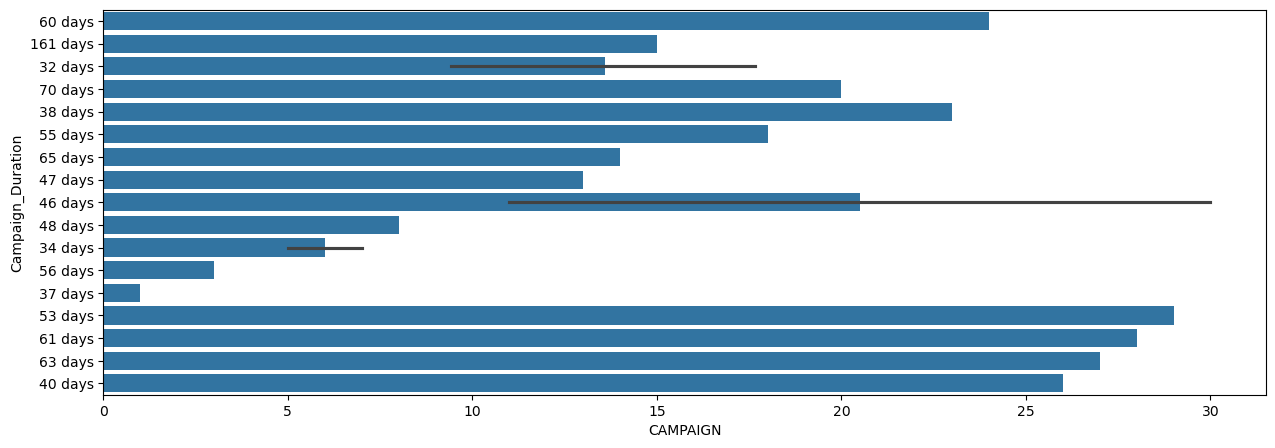

In [76]:
%matplotlib inline
plt.figure(figsize=(15,5))
sns.barplot(x='CAMPAIGN',y='Campaign_Duration',data = CAMPAIGN_DESC_RAW)
plt.show()

#### campaign lasted more than 160 days

In [77]:
CAMPAIGN_DESC_RAW.groupby('DESCRIPTION').aggregate({'CAMPAIGN':'count','Campaign_Duration':'mean'})

,CAMPAIGN,Campaign_Duration
DESCRIPTION,,
TypeA,5,47 days 04:48:00
TypeB,19,37 days 15:09:28.421052631
TypeC,6,74 days 12:00:00


**There have been 19 type B campaigns, whose average length was 38 days. In comparison, there has been 6 type C campaigns of 75 days on average.**

In [78]:
CAMPAIGN_DESC_RAW.head(2)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,Campaign_Duration
0,TypeB,24,2020-10-21,2020-12-20,60 days
1,TypeC,15,2020-07-01,2020-12-09,161 days


In [79]:
CAMPAIGN_DESC_RAW['Start_Month']=CAMPAIGN_DESC_RAW['START_DAY'].dt.strftime('%m')

In [80]:
CAMPAIGN_DESC_RAW['End_Month']=CAMPAIGN_DESC_RAW['END_DAY'].dt.strftime('%m')

In [81]:
CAMPAIGN_DESC_RAW['Start_Year']=CAMPAIGN_DESC_RAW['START_DAY'].dt.strftime('%Y')

In [82]:
CAMPAIGN_DESC_RAW['End_Year']=CAMPAIGN_DESC_RAW['END_DAY'].dt.strftime('%Y')

In [83]:
CAMPAIGN_DESC_RAW.head(10)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,Campaign_Duration,Start_Month,End_Month,Start_Year,End_Year
0,TypeB,24,2020-10-21,2020-12-20,60 days,10,12,2020,2020
1,TypeC,15,2020-07-01,2020-12-09,161 days,07,12,2020,2020
2,TypeB,25,2020-10-21,2020-11-22,32 days,10,11,2020,2020
3,TypeC,20,2020-09-07,2020-11-16,70 days,09,11,2020,2020
4,TypeB,23,2020-10-08,2020-11-15,38 days,10,11,2020,2020
5,TypeB,21,2020-09-16,2020-10-18,32 days,09,10,2020,2020
6,TypeB,22,2020-09-16,2020-10-18,32 days,09,10,2020,2020
7,TypeA,18,2020-08-10,2020-10-04,55 days,08,10,2020,2020
8,TypeB,19,2020-08-26,2020-09-27,32 days,08,09,2020,2020
9,TypeB,17,2020-07-29,2020-08-30,32 days,07,08,2020,2020


In [84]:
CAMPAIGN_DESC_RAW.dtypes

DESCRIPTION                   object
CAMPAIGN                        int8
START_DAY             datetime64[ns]
END_DAY               datetime64[ns]
Campaign_Duration    timedelta64[ns]
Start_Month                   object
End_Month                     object
Start_Year                    object
End_Year                      object
dtype: object

In [85]:
CAMPAIGN_RAW.shape

(7208, 3)

In [86]:
CAMPAIGN_RAW.head(5)

,DESCRIPTION,HOUSEHOLD_KEY,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [87]:
CAMPAIGN_RAW.columns

Index(['DESCRIPTION', 'HOUSEHOLD_KEY', 'CAMPAIGN'], dtype='object')

In [88]:
CAMPAIGN_RAW.isnull().sum()

DESCRIPTION      0
HOUSEHOLD_KEY    0
CAMPAIGN         0
dtype: int64

In [89]:
CAMPAIGN_RAW['HOUSEHOLD_KEY'].nunique()

1584

**There are 1584 household participated to the campaign, leaving 916 household who never participated to any campaign.**

In [90]:
CAMPAIGN_RAW.groupby('HOUSEHOLD_KEY')['CAMPAIGN'].count()

HOUSEHOLD_KEY
1       8
2       1
3       3
4       1
6       4
       ..
2496    5
2497    3
2498    6
2499    2
2500    8
Name: CAMPAIGN, Length: 1584, dtype: int64

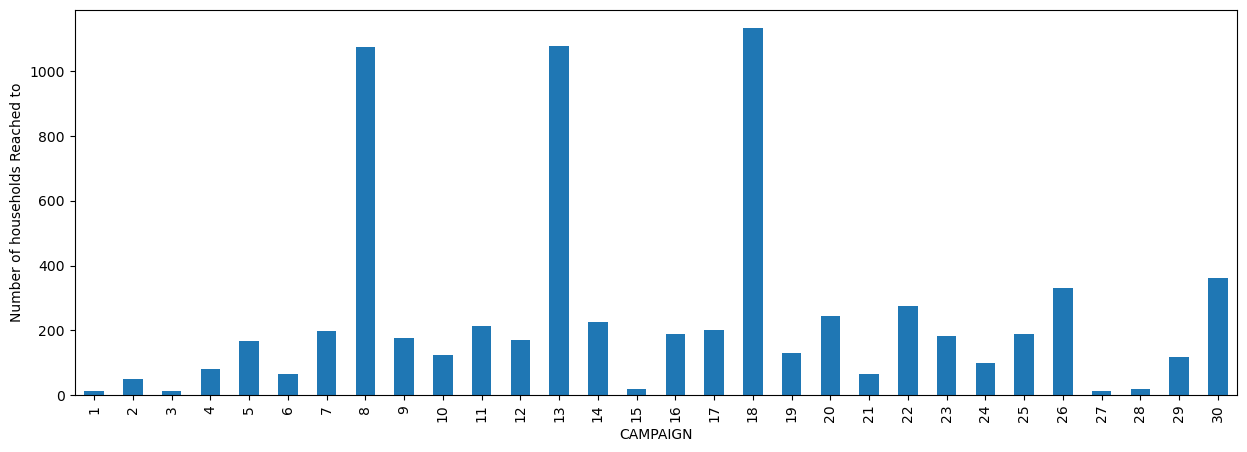

In [91]:
%matplotlib inline
plt.figure(figsize=(15,5))
CAMPAIGN_RAW.groupby('CAMPAIGN')['HOUSEHOLD_KEY'].count().plot.bar()
plt.ylabel('Number of households Reached to')
plt.show()

**In Compaigning 18 maximum number of household participated**

In [92]:
COUPON_RAW.shape

(124548, 3)

In [93]:
COUPON_RAW.columns

Index(['COUPON_UPC', 'PRODUCT_ID', 'CAMPAIGN'], dtype='object')

In [94]:
COUPON_RAW['COUPON_UPC'].nunique()

1135

In [95]:
Coupon_Given=COUPON_RAW.groupby("CAMPAIGN").aggregate(Total_product = ('PRODUCT_ID','nunique'),
                                                    Total_Coupon_Given = ('COUPON_UPC','nunique'))

In [96]:
Coupon_Given.sort_values(by='Total_product',ascending=False).head(10)

,Total_product,Total_Coupon_Given
CAMPAIGN,,
13,35616,207
18,35513,209
8,17178,209
26,3396,181
30,3205,181
22,1917,21
24,1887,2
16,1025,13
25,826,17


In [97]:
Coupon_Given.head(10)

,Total_product,Total_Coupon_Given
CAMPAIGN,,
1,383,11
2,301,16
3,506,34
4,200,12
5,443,11
6,18,1
7,259,8
8,17178,209
9,825,18


In [98]:
CAMPAIGN_DESC_RAW.head(2)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,Campaign_Duration,Start_Month,End_Month,Start_Year,End_Year
0,TypeB,24,2020-10-21,2020-12-20,60 days,10,12,2020,2020
1,TypeC,15,2020-07-01,2020-12-09,161 days,07,12,2020,2020


In [99]:
Coupon_Given=Coupon_Given.merge(right=CAMPAIGN_DESC_RAW,on='CAMPAIGN',how='left')

In [100]:
Coupon_Given

,CAMPAIGN,Total_product,Total_Coupon_Given,DESCRIPTION,START_DAY,END_DAY,Campaign_Duration,Start_Month,End_Month,Start_Year,End_Year
0,1,383,11,TypeB,2019-12-13,2020-01-19,37 days,12,01,2019,2020
1,2,301,16,TypeB,2019-12-18,2020-01-19,32 days,12,01,2019,2020
2,3,506,34,TypeC,2019-12-23,2020-02-17,56 days,12,02,2019,2020
3,4,200,12,TypeB,2020-01-08,2020-02-09,32 days,01,02,2020,2020
4,5,443,11,TypeB,2020-01-13,2020-02-16,34 days,01,02,2020,2020
5,6,18,1,TypeC,2020-01-29,2020-03-01,32 days,01,03,2020,2020
6,7,259,8,TypeB,2020-02-03,2020-03-08,34 days,02,03,2020,2020
7,8,17178,209,TypeA,2020-02-17,2020-04-05,48 days,02,04,2020,2020
8,9,825,18,TypeB,2020-03-11,2020-04-12,32 days,03,04,2020,2020
9,10,393,14,TypeB,2020-04-08,2020-05-10,32 days,04,05,2020,2020


In [101]:
Coupon_Given.columns

Index(['CAMPAIGN', 'Total_product', 'Total_Coupon_Given', 'DESCRIPTION',
       'START_DAY', 'END_DAY', 'Campaign_Duration', 'Start_Month', 'End_Month',
       'Start_Year', 'End_Year'],
      dtype='object')

In [102]:
Coupon_Given.loc[:,('CAMPAIGN', 'Total_product', 'Total_Coupon_Given', 'DESCRIPTION','Start_Year', 'End_Year','Start_Month', 'End_Month',
       'Start_Year', 'End_Year','Campaign_Duration')].sort_values(by='Total_product',ascending=False).head(5)

,CAMPAIGN,Total_product,Total_Coupon_Given,DESCRIPTION,Start_Year,End_Year,Start_Month,End_Month,Start_Year,End_Year,Campaign_Duration
12,13,35616,207,TypeA,2020,2020,05,07,2020,2020,47 days
17,18,35513,209,TypeA,2020,2020,08,10,2020,2020,55 days
7,8,17178,209,TypeA,2020,2020,02,04,2020,2020,48 days
25,26,3396,181,TypeA,2019,2019,08,09,2019,2019,40 days
29,30,3205,181,TypeA,2019,2020,11,01,2019,2020,46 days


In [103]:
COUPON_RAW.head(5)

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [104]:
PRODUCT_RAW.head(5)

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


**Campaign 13,18,8 are the one with most product in them**

In [105]:
coupon_product = COUPON_RAW.merge(right=PRODUCT_RAW,on='PRODUCT_ID',how='left')

In [106]:
coupon_product

,COUPON_UPC,PRODUCT_ID,CAMPAIGN,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,10000089061,27160,4,69,GROCERY,Private,SHORTENING/OIL,VEGETABLE/SALAD OIL,48 OZ
1,10000089064,27754,9,69,GROCERY,Private,FRZN VEGETABLE/VEG DSH,FRZN BAGGED VEGETABLES - PLAIN,16 OZ
2,10000089073,28897,12,69,GROCERY,Private,EGGS,EGGS - X-LARGE,A D 1 DZ
3,51800009050,28919,28,236,GROCERY,National,REFRGRATD DOUGH PRODUCTS,REFRIGERATED COOKIES-CHUB,16.5 OZ
4,52100000076,28929,25,317,GROCERY,National,CHEESE,STRING CHEESE,AB 8 OZ
...,...,...,...,...,...,...,...,...,...
124543,10000085478,13038802,18,1119,DRUG GM,National,AUDIO/VIDEO PRODUCTS,PARFUMS DE COUER,
124544,10000085479,13039368,18,2875,MEAT,National,BEEF,CHOICE BEEF,
124545,10000085478,13039553,18,1229,DRUG GM,National,STATIONERY & SCHOOL SUPPLIES,BONNE BELL,
124546,10000085479,13776332,18,4824,MEAT,National,SMOKED MEATS,HAMS-HALF/PORT BONELESS,


In [107]:
coupon_product.isnull().sum()

COUPON_UPC              0
PRODUCT_ID              0
CAMPAIGN                0
MANUFACTURER            0
DEPARTMENT              0
BRAND                   0
COMMODITY_DESC          0
SUB_COMMODITY_DESC      0
CURR_SIZE_OF_PRODUCT    0
dtype: int64

**Top 10 Product on which coupon has been applied**

In [108]:
coupon_product['COMMODITY_DESC'].value_counts().head(10)

COMMODITY_DESC
HAIR CARE PRODUCTS        6261
MAKEUP AND TREATMENT      5585
FRZN MEAT/MEAT DINNERS    4893
FROZEN PIZZA              3658
BEEF                      3314
ICE CREAM/MILK/SHERBTS    3257
CHEESE                    3146
YOGURT                    2460
ORAL HYGIENE PRODUCTS     2437
LUNCHMEAT                 2425
Name: count, dtype: int64

**Most prominent products among coupons created are bathroom products such as hair care and makeup.**

In [109]:
COUPON_REDEMPT_RAW.shape

(2318, 5)

In [110]:
COUPON_REDEMPT_RAW.columns

Index(['HOUSEHOLD_KEY', 'DAY', 'COUPON_UPC', 'CAMPAIGN', 'Date'], dtype='object')

In [111]:
COUPON_REDEMPT_RAW['COUPON_UPC'].nunique()

556

In [112]:
COUPON_REDEMPT_RAW.head(2)

,HOUSEHOLD_KEY,DAY,COUPON_UPC,CAMPAIGN,Date
0,1,421,10000085364,8,2020-02-26
1,1,421,51700010076,8,2020-02-26


**Only 556 coupon has been used**

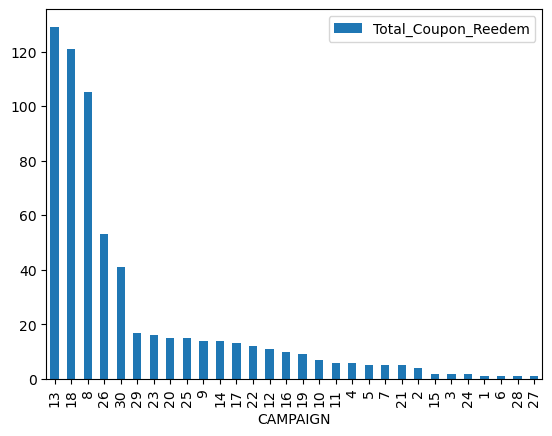

In [113]:
%matplotlib inline
COUPON_REDEMPT_RAW.groupby('CAMPAIGN').agg(Total_Coupon_Reedem=('COUPON_UPC','nunique')).sort_values(by='Total_Coupon_Reedem',ascending=False).plot.bar()
plt.show()

In [114]:
coupon_redeem = COUPON_REDEMPT_RAW.groupby('CAMPAIGN').agg(Total_Coupon_Reedem=('COUPON_UPC','nunique'))

In [115]:
coupon_redeem.sort_values(by='Total_Coupon_Reedem',ascending=False)

,Total_Coupon_Reedem
CAMPAIGN,
13,129
18,121
8,105
26,53
30,41
29,17
23,16
20,15
25,15


In [116]:
coupon_redeem.head(2)

,Total_Coupon_Reedem
CAMPAIGN,
1,1
2,4


In [117]:
Coupon_Given.head(2)

,CAMPAIGN,Total_product,Total_Coupon_Given,DESCRIPTION,START_DAY,END_DAY,Campaign_Duration,Start_Month,End_Month,Start_Year,End_Year
0,1,383,11,TypeB,2019-12-13,2020-01-19,37 days,12,01,2019,2020
1,2,301,16,TypeB,2019-12-18,2020-01-19,32 days,12,01,2019,2020


In [118]:
coupon_redeem=coupon_redeem.merge(right=Coupon_Given,on='CAMPAIGN',how='left')

In [119]:
coupon_redeem.head(2)

,CAMPAIGN,Total_Coupon_Reedem,Total_product,Total_Coupon_Given,DESCRIPTION,START_DAY,END_DAY,Campaign_Duration,Start_Month,End_Month,Start_Year,End_Year
0,1,1,383,11,TypeB,2019-12-13,2020-01-19,37 days,12,01,2019,2020
1,2,4,301,16,TypeB,2019-12-18,2020-01-19,32 days,12,01,2019,2020


In [120]:
coupon_redeem['Coupon_Reedemption_Rate']=(coupon_redeem['Total_Coupon_Reedem']/coupon_redeem['Total_Coupon_Given'])*100

In [121]:
coupon_redeem.sort_values(by='Coupon_Reedemption_Rate',ascending=False)

,CAMPAIGN,Total_Coupon_Reedem,Total_product,Total_Coupon_Given,DESCRIPTION,START_DAY,END_DAY,Campaign_Duration,Start_Month,End_Month,Start_Year,End_Year,Coupon_Reedemption_Rate
5,6,1,18,1,TypeC,2020-01-29,2020-03-01,32 days,01,03,2020,2020,100.000000
14,15,2,55,2,TypeC,2020-07-01,2020-12-09,161 days,07,12,2020,2020,100.000000
23,24,2,1887,2,TypeB,2020-10-21,2020-12-20,60 days,10,12,2020,2020,100.000000
22,23,16,767,18,TypeB,2020-10-08,2020-11-15,38 days,10,11,2020,2020,88.888889
24,25,15,826,17,TypeB,2020-10-21,2020-11-22,32 days,10,11,2020,2020,88.235294
18,19,9,375,11,TypeB,2020-08-26,2020-09-27,32 days,08,09,2020,2020,81.818182
8,9,14,825,18,TypeB,2020-03-11,2020-04-12,32 days,03,04,2020,2020,77.777778
15,16,10,1025,13,TypeB,2020-07-15,2020-08-16,32 days,07,08,2020,2020,76.923077
11,12,11,620,15,TypeB,2020-04-22,2020-05-24,32 days,04,05,2020,2020,73.333333
16,17,13,713,19,TypeB,2020-07-29,2020-08-30,32 days,07,08,2020,2020,68.421053


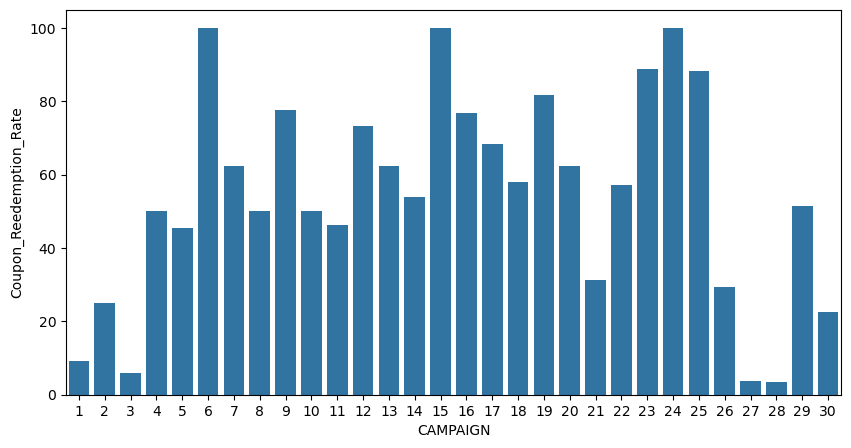

In [122]:
%matplotlib inline
plt.figure(figsize=(10,5))
sns.barplot(x='CAMPAIGN',y='Coupon_Reedemption_Rate',data=coupon_redeem)
plt.show()

In [123]:
TRANSACTION_RAW.head(2)

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,DATE
0,2056,29330027026,177,1106523,1,2.32,341,0.0,4,26,0,0,2019-06-27
1,2056,29330027026,177,5567325,1,2.69,341,0.0,4,26,0,0,2019-06-27


In [124]:
TRANSACTION_RAW.shape

(1858364, 13)

In [125]:
TRANSACTION_RAW.columns

Index(['HOUSEHOLD_KEY', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY',
       'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO',
       'COUPON_DISC', 'COUPON_MATCH_DISC', 'DATE'],
      dtype='object')

In [126]:
TRANSACTION_RAW.isnull().sum()

HOUSEHOLD_KEY        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
DATE                 0
dtype: int64

In [127]:
TRANSACTION_RAW['BASKET_ID'].count()

np.int64(1858364)

In [128]:
TRANSACTION_RAW['BASKET_ID'].nunique()

200764

In [129]:
TRANSACTION_RAW['HOUSEHOLD_KEY'].nunique()

2498

In [130]:
trnx_bucket=TRANSACTION_RAW.groupby('BASKET_ID').agg({'SALES_VALUE':'sum','COUPON_DISC':'sum','COUPON_MATCH_DISC':'sum'})

In [131]:
trnx_bucket.head(2)

,SALES_VALUE,COUPON_DISC,COUPON_MATCH_DISC
BASKET_ID,,,
26984851472,5.91,0,0
26984851516,12.43,0,0


In [132]:
trnx_bucket['use_coupon']=trnx_bucket['COUPON_DISC']!=0

In [133]:
trnx_bucket['use_coupon'].value_counts()

use_coupon
False    189658
True      11106
Name: count, dtype: int64

In [134]:
trnx_bucket.sort_values('SALES_VALUE',ascending=False).head(10)

,SALES_VALUE,COUPON_DISC,COUPON_MATCH_DISC,use_coupon
BASKET_ID,,,,
32006114302,961.49,0,0,False
33347880492,552.92,-3,0,True
32505140858,545.17,0,0,False
30983766334,545.07,0,0,False
35638473903,543.83,0,0,False
34267311742,518.01,0,0,False
30515165970,508.58,0,0,False
32187143334,499.99,0,0,False
32932343176,472.87,0,0,False


In [135]:
round(trnx_bucket['SALES_VALUE'].mean(),2)

np.float64(28.53)

**The Average Basket Value is $26.93**

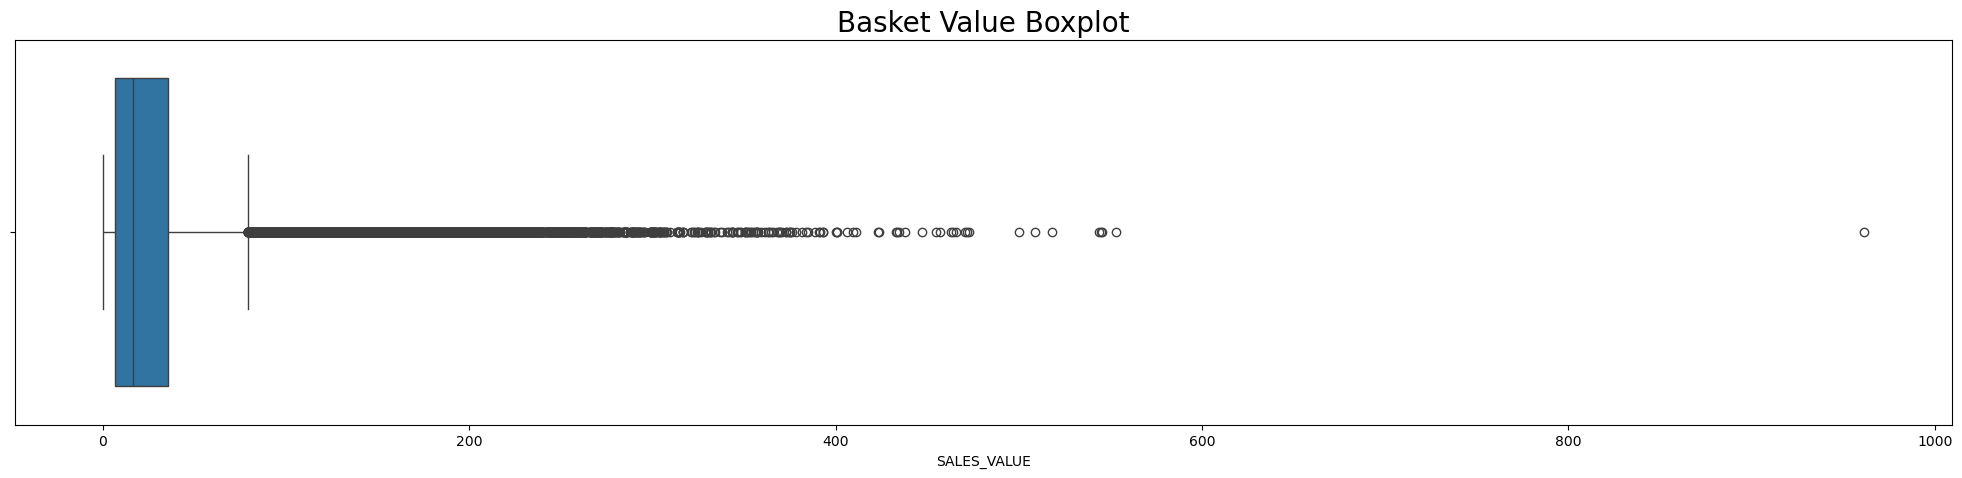

In [136]:
%matplotlib inline
plt.figure(figsize=(25,5))
sns.boxplot(x=trnx_bucket['SALES_VALUE'])
plt.title('Basket Value Boxplot', fontsize=20)
plt.show()

In [137]:
trnx_bucket.head(3)

,SALES_VALUE,COUPON_DISC,COUPON_MATCH_DISC,use_coupon
BASKET_ID,,,,
26984851472,5.91,0,0,False
26984851516,12.43,0,0,False
26984896261,11.37,0,0,False


In [138]:
trnx_bucket.groupby('use_coupon').agg(sales_mean=('SALES_VALUE','mean'),
                                      coupon_disc_mean=('COUPON_DISC','mean'),
                                      coupon_match_disc_mean=('COUPON_MATCH_DISC','mean'),
                                      use_coupon_count=('use_coupon','count'))

,sales_mean,coupon_disc_mean,coupon_match_disc_mean,use_coupon_count
use_coupon,,,,
False,26.304752,0.000000,-0.000021,189658
True,66.603714,-2.919863,-0.399064,11106


The Average basket value without coupon is $26.79

The Average basket value with a coupon is $68.21

The Average discount generated by coupon is $2.98

**It shows that customer purchase more product when coupon is given to them**

In [139]:
trnx_desc=TRANSACTION_RAW.merge(right=trnx_bucket,on='BASKET_ID',how='left')

In [140]:
trnx_desc

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE_x,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC_x,COUPON_MATCH_DISC_x,DATE,SALES_VALUE_y,COUPON_DISC_y,COUPON_MATCH_DISC_y,use_coupon
0,2056,29330027026,177,1106523,1,2.32,341,0.00,4,26,0,0,2019-06-27,5.01,0,0,False
1,2056,29330027026,177,5567325,1,2.69,341,0.00,4,26,0,0,2019-06-27,5.01,0,0,False
2,2056,29330027027,177,1106523,1,2.32,341,0.00,4,26,0,0,2019-06-27,2.32,0,0,False
3,1873,29330097522,177,1135681,1,1.29,320,0.00,1,26,0,0,2019-06-27,1.29,0,0,False
4,1602,29339301484,177,828427,1,0.22,334,-0.07,1537,26,0,0,2019-06-27,101.20,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1858359,1662,33472847050,440,9419982,1,2.39,400,0.00,1648,64,0,0,2020-03-16,133.18,0,0,False
1858360,1662,33472847050,440,9670830,1,4.79,400,0.00,1648,64,0,0,2020-03-16,133.18,0,0,False
1858361,1662,33472847050,440,9707078,1,2.50,400,-0.49,1648,64,0,0,2020-03-16,133.18,0,0,False
1858362,1662,33472847050,440,9707461,1,2.50,400,-0.49,1648,64,0,0,2020-03-16,133.18,0,0,False


In [141]:
trnx_desc=trnx_desc.merge(right=PRODUCT_RAW,on='PRODUCT_ID',how='left')

In [142]:
trnx_desc

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE_x,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,SALES_VALUE_y,COUPON_DISC_y,COUPON_MATCH_DISC_y,use_coupon,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,2056,29330027026,177,1106523,1,2.32,341,0.00,4,26,...,5.01,0,0,False,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
1,2056,29330027026,177,5567325,1,2.69,341,0.00,4,26,...,5.01,0,0,False,531,GROCERY,National,CANNED JUICES,BLENDED JUICE&COMBINATIONS (50,46 OZ
2,2056,29330027027,177,1106523,1,2.32,341,0.00,4,26,...,2.32,0,0,False,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
3,1873,29330097522,177,1135681,1,1.29,320,0.00,1,26,...,1.29,0,0,False,1600,DRUG GM,National,BABY FOODS,BABY SPRING WATERS,
4,1602,29339301484,177,828427,1,0.22,334,-0.07,1537,26,...,101.20,0,0,False,69,GROCERY,Private,CAT FOOD,CANNED CAT FOOD (9 LIVES/FRISK,5.5 OZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1858359,1662,33472847050,440,9419982,1,2.39,400,0.00,1648,64,...,133.18,0,0,False,1527,GROCERY,National,DRY NOODLES/PASTA,MACARONI DRY,12 OZ
1858360,1662,33472847050,440,9670830,1,4.79,400,0.00,1648,64,...,133.18,0,0,False,69,GROCERY,Private,PAPER HOUSEWARES,DESIGNER PAPER: MEDIUM WEIGHT,115 CT
1858361,1662,33472847050,440,9707078,1,2.50,400,-0.49,1648,64,...,133.18,0,0,False,1094,MEAT-PCKGD,National,HEAT/SERVE,SANDWICHES-OTHER,6.45 OZ
1858362,1662,33472847050,440,9707461,1,2.50,400,-0.49,1648,64,...,133.18,0,0,False,1094,MEAT-PCKGD,National,HEAT/SERVE,SANDWICHES-OTHER,7.85 OZ


In [143]:
trnx_desc.drop(['SALES_VALUE_y','COUPON_DISC_y','COUPON_MATCH_DISC_y'],axis=1,inplace=True)

In [144]:
trnx_desc

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE_x,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC_x,COUPON_MATCH_DISC_x,DATE,use_coupon,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,2056,29330027026,177,1106523,1,2.32,341,0.00,4,26,0,0,2019-06-27,False,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
1,2056,29330027026,177,5567325,1,2.69,341,0.00,4,26,0,0,2019-06-27,False,531,GROCERY,National,CANNED JUICES,BLENDED JUICE&COMBINATIONS (50,46 OZ
2,2056,29330027027,177,1106523,1,2.32,341,0.00,4,26,0,0,2019-06-27,False,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
3,1873,29330097522,177,1135681,1,1.29,320,0.00,1,26,0,0,2019-06-27,False,1600,DRUG GM,National,BABY FOODS,BABY SPRING WATERS,
4,1602,29339301484,177,828427,1,0.22,334,-0.07,1537,26,0,0,2019-06-27,False,69,GROCERY,Private,CAT FOOD,CANNED CAT FOOD (9 LIVES/FRISK,5.5 OZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1858359,1662,33472847050,440,9419982,1,2.39,400,0.00,1648,64,0,0,2020-03-16,False,1527,GROCERY,National,DRY NOODLES/PASTA,MACARONI DRY,12 OZ
1858360,1662,33472847050,440,9670830,1,4.79,400,0.00,1648,64,0,0,2020-03-16,False,69,GROCERY,Private,PAPER HOUSEWARES,DESIGNER PAPER: MEDIUM WEIGHT,115 CT
1858361,1662,33472847050,440,9707078,1,2.50,400,-0.49,1648,64,0,0,2020-03-16,False,1094,MEAT-PCKGD,National,HEAT/SERVE,SANDWICHES-OTHER,6.45 OZ
1858362,1662,33472847050,440,9707461,1,2.50,400,-0.49,1648,64,0,0,2020-03-16,False,1094,MEAT-PCKGD,National,HEAT/SERVE,SANDWICHES-OTHER,7.85 OZ


In [145]:
commodity_coupon=trnx_desc.groupby('COMMODITY_DESC').agg(Total_quantity=('QUANTITY','count'),
                                                        use_coupon=('use_coupon','sum'),
                                                        coupon=('COUPON_DISC_x','sum'))

In [146]:
commodity_coupon.sort_values(by='use_coupon',ascending=False).head(10)

,Total_quantity,use_coupon,coupon
COMMODITY_DESC,,,
SOFT DRINKS,86994,9953,-3943
BAKED BREAD/BUNS/ROLLS,60410,7864,-366
CHEESE,52525,7730,-318
FLUID MILK PRODUCTS,60881,7117,-285
FRZN MEAT/MEAT DINNERS,39544,6471,-635
BAG SNACKS,48382,6060,-356
YOGURT,32442,5589,-614
FROZEN PIZZA,31142,4981,-558
SOUP,30100,4643,-306


In [147]:
commodity_coupon['coupon%']=round((commodity_coupon['use_coupon']/commodity_coupon['Total_quantity'])*100,2)

In [148]:
commodity_coupon

,Total_quantity,use_coupon,coupon,coupon%
COMMODITY_DESC,,,,
,5311,4003,-6929,75.37
(CORP USE ONLY),43,1,0,2.33
ADULT INCONTINENCE,380,55,-27,14.47
AIR CARE,3872,896,-574,23.14
ANALGESICS,3175,439,-7,13.83
...,...,...,...,...
WAREHOUSE SNACKS,6828,969,-77,14.19
WATCHES/CALCULATORS/LOBBY,34,1,0,2.94
WATER,1500,102,0,6.80


In [149]:
commodity_coupon.sort_values(by='coupon%',ascending=False).head(10)

,Total_quantity,use_coupon,coupon,coupon%
COMMODITY_DESC,,,,
,5311,4003,-6929,75.37
RESTRICTED DIET,42,12,0,28.57
BABY FOODS,15192,4288,-241,28.23
FRZN SEAFOOD,34,9,0,26.47
DIAPERS & DISPOSABLES,3526,854,-710,24.22
AIR CARE,3872,896,-574,23.14
BABY HBC,3276,734,-256,22.41
FROZEN - BOXED(GROCERY),637,142,-35,22.29
NATURAL VITAMINS,14,3,-5,21.43


**The Most prominents product for which coupon were created are haircare and makeup products,coupons mostly used in food items**

In [150]:
TRANSACTION_RAW.head(2)

,HOUSEHOLD_KEY,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,DATE
0,2056,29330027026,177,1106523,1,2.32,341,0.0,4,26,0,0,2019-06-27
1,2056,29330027026,177,5567325,1,2.69,341,0.0,4,26,0,0,2019-06-27


In [151]:
TRANSACTION_RAW.groupby(['HOUSEHOLD_KEY','WEEK_NO','DAY']).agg({'SALES_VALUE':'sum','RETAIL_DISC':'sum','COUPON_DISC':'sum','COUPON_MATCH_DISC':'sum'})

SALES_VALUE  RETAIL_DISC  COUPON_DISC  \
HOUSEHOLD_KEY WEEK_NO DAY                                          
1             8       51         78.66       -16.54           -1   
              10      67         41.10        -8.59            0   
              13      88         26.90        -6.72            0   
              14      94         63.43       -11.08           -2   
              15      101        53.45       -16.42            0   
...                                ...          ...          ...   
2500          73      507       166.64       -25.64            0   
              74      512        62.80        -0.01            0   
                      514        52.61        -2.95           -4   
              76      525        40.49       -17.62           -3   
                      526        57.01        -2.24            0   

                           COUPON_MATCH_DISC  
HOUSEHOLD_KEY WEEK_NO DAY                     
1             8       51                   0  
              10      67                   0  
              13      88                   0  
              14      94                  -1  
              15      101                  0  
...                                      ...  
2500          73      507                  0  
              74      512                  0  
                      514                  0  
              76      525                  0  
                      526                  0  

[162855 rows x 4 columns]

In [152]:
TRANSACTION_RAW.groupby(TRANSACTION_RAW['DATE'].dt.year).agg({'SALES_VALUE':'sum','RETAIL_DISC':'sum','COUPON_DISC':'sum'})

,SALES_VALUE,RETAIL_DISC,COUPON_DISC
DATE,,,
2019,3636562.00,-639843.50,-18813
2020,2092045.41,-370116.67,-13615


**Sales value increases as Retail discout and coupon discount increases**

**Dropping the Columns**

In [153]:
from datetime import datetime

In [154]:
CAMPAIGN_DESC_RAW.head(2)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,Campaign_Duration,Start_Month,End_Month,Start_Year,End_Year
0,TypeB,24,2020-10-21,2020-12-20,60 days,10,12,2020,2020
1,TypeC,15,2020-07-01,2020-12-09,161 days,07,12,2020,2020


In [155]:
type(CAMPAIGN_DESC_RAW['START_DAY'])

pandas.core.series.Series

In [156]:
CAMPAIGN_DESC_RAW.dtypes

DESCRIPTION                   object
CAMPAIGN                        int8
START_DAY             datetime64[ns]
END_DAY               datetime64[ns]
Campaign_Duration    timedelta64[ns]
Start_Month                   object
End_Month                     object
Start_Year                    object
End_Year                      object
dtype: object

In [157]:
CAMPAIGN_DESC_RAW['START_DAY']=pd.to_datetime(CAMPAIGN_DESC_RAW['START_DAY']).apply(lambda x: x.date())

In [158]:
type(CAMPAIGN_DESC_RAW['START_DAY'])

pandas.core.series.Series

In [159]:
CAMPAIGN_DESC_RAW['START_DAY']

0     2020-10-21
1     2020-07-01
2     2020-10-21
3     2020-09-07
4     2020-10-08
5     2020-09-16
6     2020-09-16
7     2020-08-10
8     2020-08-26
9     2020-07-29
10    2020-06-15
11    2020-07-15
12    2020-05-19
13    2020-04-22
14    2020-04-22
15    2020-04-08
16    2020-03-11
17    2020-02-17
18    2020-02-03
19    2020-01-29
20    2019-12-23
21    2020-01-13
22    2020-01-08
23    2019-12-13
24    2019-12-18
25    2019-11-20
26    2019-10-09
27    2019-09-17
28    2019-08-26
29    2019-08-13
Name: START_DAY, dtype: object

In [160]:
CAMPAIGN_DESC_RAW.dtypes

DESCRIPTION                   object
CAMPAIGN                        int8
START_DAY                     object
END_DAY               datetime64[ns]
Campaign_Duration    timedelta64[ns]
Start_Month                   object
End_Month                     object
Start_Year                    object
End_Year                      object
dtype: object

In [161]:
CAMPAIGN_DESC_RAW['END_DAY']=pd.to_datetime(CAMPAIGN_DESC_RAW['END_DAY']).apply(lambda x: x.date())

In [162]:
CAMPAIGN_DESC_RAW.dtypes

DESCRIPTION                   object
CAMPAIGN                        int8
START_DAY                     object
END_DAY                       object
Campaign_Duration    timedelta64[ns]
Start_Month                   object
End_Month                     object
Start_Year                    object
End_Year                      object
dtype: object

In [163]:
COUPON_REDEMPT_RAW.head(2)

,HOUSEHOLD_KEY,DAY,COUPON_UPC,CAMPAIGN,Date
0,1,421,10000085364,8,2020-02-26
1,1,421,51700010076,8,2020-02-26


In [164]:
COUPON_REDEMPT_RAW.drop(['DAY'],axis=1,inplace=True)

In [165]:
COUPON_REDEMPT_RAW.head(2)

,HOUSEHOLD_KEY,COUPON_UPC,CAMPAIGN,Date
0,1,10000085364,8,2020-02-26
1,1,51700010076,8,2020-02-26


In [166]:
COUPON_REDEMPT_RAW.dtypes

HOUSEHOLD_KEY             int16
COUPON_UPC                int64
CAMPAIGN                   int8
Date             datetime64[ns]
dtype: object

In [167]:
COUPON_REDEMPT_RAW['Date']=pd.to_datetime(COUPON_REDEMPT_RAW['Date']).apply(lambda x: x.date())

In [168]:
COUPON_REDEMPT_RAW.dtypes

HOUSEHOLD_KEY     int16
COUPON_UPC        int64
CAMPAIGN           int8
Date             object
dtype: object

In [169]:
TRANSACTION_RAW.drop(['DAY','WEEK_NO'],axis=1,inplace=True)

In [170]:
TRANSACTION_RAW.head()

,HOUSEHOLD_KEY,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,COUPON_DISC,COUPON_MATCH_DISC,DATE
0,2056,29330027026,1106523,1,2.32,341,0.00,4,0,0,2019-06-27
1,2056,29330027026,5567325,1,2.69,341,0.00,4,0,0,2019-06-27
2,2056,29330027027,1106523,1,2.32,341,0.00,4,0,0,2019-06-27
3,1873,29330097522,1135681,1,1.29,320,0.00,1,0,0,2019-06-27
4,1602,29339301484,828427,1,0.22,334,-0.07,1537,0,0,2019-06-27


In [171]:
TRANSACTION_RAW.dtypes

HOUSEHOLD_KEY                 int16
BASKET_ID                     int64
PRODUCT_ID                    int32
QUANTITY                      int32
SALES_VALUE                 float64
STORE_ID                      int32
RETAIL_DISC                 float64
TRANS_TIME                    int16
COUPON_DISC                    int8
COUPON_MATCH_DISC              int8
DATE                 datetime64[ns]
dtype: object

In [172]:
TRANSACTION_RAW['DATE']=pd.to_datetime(TRANSACTION_RAW['DATE']).apply(lambda x: x.date())

In [173]:
TRANSACTION_RAW.dtypes

HOUSEHOLD_KEY          int16
BASKET_ID              int64
PRODUCT_ID             int32
QUANTITY               int32
SALES_VALUE          float64
STORE_ID               int32
RETAIL_DISC          float64
TRANS_TIME             int16
COUPON_DISC             int8
COUPON_MATCH_DISC       int8
DATE                  object
dtype: object

**Now Loading the table to DB**

In [174]:
from sqlalchemy import create_engine
from sqlalchemy.engine import url
import snowflake.connector as snowCtx
from snowflake.connector.pandas_tools import write_pandas
import pandas as pd
import getpass

In [175]:
conn = snowflake.connector.connect(
        user = 'Moni',
        ##password = getpass.getpass('Your Snowflake Password: ')
        password='Moni@1234567890',
        account = 'CNXLYPS-NB32912',
        database='RETAILS',
        warehouse='COMPUTE_WH',
        SCHEMA='PUBLIC',
        schema ='PUBLIC'
 ) 

In [176]:
cur=conn.cursor()

In [177]:
CAMPAIGN_DESC_RAW.head(2)       # clean raw dataframe

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,Campaign_Duration,Start_Month,End_Month,Start_Year,End_Year
0,TypeB,24,2020-10-21,2020-12-20,60 days,10,12,2020,2020
1,TypeC,15,2020-07-01,2020-12-09,161 days,07,12,2020,2020


In [178]:
success, nchunks, nrows, _ = write_pandas(conn, CAMPAIGN_DESC_RAW,'CAMPAIGN_DESC_NEW',quote_identifiers=False,auto_create_table=True)
print(str(success)+','+str(nchunks)+','+str(nrows))

True,1,30


In [179]:
success, nchunks, nrows, _ = write_pandas(conn, COUPON_REDEMPT_RAW,'COUPON_REDEMPT_NEW',quote_identifiers=False,auto_create_table=True)
print(str(success)+','+str(nchunks)+','+str(nrows))

True,1,2318


In [180]:
success, nchunks, nrows, _ = write_pandas(conn,TRANSACTION_RAW ,'TRANSACTION_NEW',quote_identifiers=False,auto_create_table=True)
print(str(success)+','+str(nchunks)+','+str(nrows))

True,1,1858364


In [181]:
cur.close()
conn.close()